<a href="https://colab.research.google.com/github/manluz555-ops/Line_progr/blob/main/HW_7_Manzar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашня робота № 7
Манзар Л.В.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Розмір датасету: (14861, 2)
Після очищення: label
1    7813
0    7047
Name: count, dtype: int64
Новий розмір збалансованого датасету: (10000, 2)


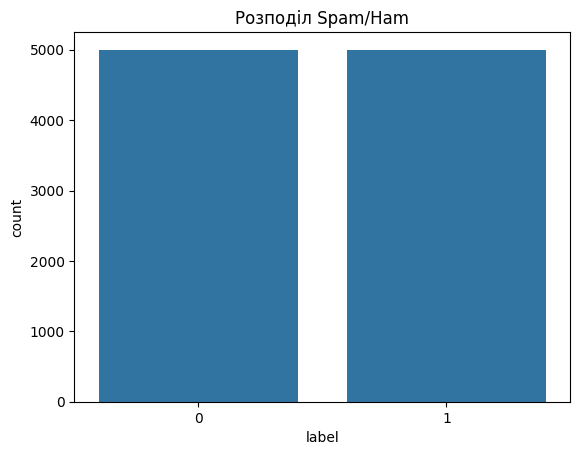

spam1 -> SPAM
ham1 -> HAM
spam2 -> HAM
ham2 -> HAM

Найчастіші слова у спамі:
escapenumber -> 0.006
http -> 0.0049
com -> 0.0036
price -> 0.0031
one -> 0.0031
u -> 0.0031
time -> 0.0027
day -> 0.0026
get -> 0.0025
escapelong -> 0.0023
please -> 0.0021
see -> 0.0021
like -> 0.0021
new -> 0.002
offer -> 0.002
e -> 0.002
may -> 0.002
best -> 0.0019
product -> 0.0019
www -> 0.0019


In [1]:
# 1. Імпорт бібліотек
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Завантаження ресурсів NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# 2. Завантаження датасету з Google Drive
df = pd.read_csv('/content/drive/MyDrive/Домашнє завдання/Лінійне програмування/HW_7/combined_data.csv')
print("Розмір датасету:", df.shape)

# 3. Очищення колонки label
df['label'] = df['label'].astype(str).str.strip()   # прибираємо пробіли
df = df[df['label'].isin(['0','1'])]                # залишаємо тільки 0 і 1
df['label'] = df['label'].astype(int)               # переводимо назад у числа
print("Після очищення:", df['label'].value_counts())

# 4. Балансування вибірки (по 5000 записів з кожного класу)
spam_df = df[df['label'] == 1].sample(5000, random_state=42)
ham_df = df[df['label'] == 0].sample(5000, random_state=42)
df = pd.concat([spam_df, ham_df])
print("Новий розмір збалансованого датасету:", df.shape)

# 5. Візуалізація
sns.countplot(x="label", data=df)
plt.title("Розподіл Spam/Ham")
plt.show()

# 6. Попередня обробка текстів
corpus = []
for document in df["text"]:
    document = re.sub("[^a-zA-Z]", " ", document).lower()
    document = document.split()
    document = [lemmatizer.lemmatize(word) for word in document if word not in stop_words]
    document = list(set(document))
    corpus.append(" ".join(document))

df["text"] = corpus

# 7. Підготовка структур даних
train_spam = df[df['label'] == 1]['text'].tolist()
train_ham = df[df['label'] == 0]['text'].tolist()

test_emails = {
    "spam1": "Congratulations! You won a free prize, click here!",
    "ham1": "Hi, let's meet tomorrow for coffee.",
    "spam2": "Cheap loans available now, apply instantly!",
    "ham2": "Your meeting is scheduled for Monday at 10 AM."
}

# 8. Реалізація алгоритму наївного Баєса
def word_probabilities(messages, label):
    word_counts = {}
    for msg in messages:
        for word in msg.split():
            word_counts[word] = word_counts.get(word, 0) + 1
    total_words = sum(word_counts.values())
    return {word: (count / total_words, label) for word, count in word_counts.items()}

spam_probs = word_probabilities(train_spam, 1)
ham_probs = word_probabilities(train_ham, 0)

def predict(message):
    words = message.split()
    spam_score, ham_score = 1, 1
    for word in words:
        if word in spam_probs:
            spam_score *= spam_probs[word][0]
        if word in ham_probs:
            ham_score *= ham_probs[word][0]
    return 1 if spam_score > ham_score else 0

# 9. Перевірка на тестових повідомленнях
for name, msg in test_emails.items():
    print(name, "->", "SPAM" if predict(msg) == 1 else "HAM")

# 10. Аналіз найбільш «спамових» слів
sorted_spam = sorted(spam_probs.items(), key=lambda x: x[1][0], reverse=True)[:20]
print("\nНайчастіші слова у спамі:")
for word, (prob, _) in sorted_spam:
    print(word, "->", round(prob, 4))




## Висновки

1. Було завантажено та очищено набір даних **Email Spam Classification Dataset**, що містив понад 14 тисяч повідомлень. Після попередньої обробки залишено лише валідні записи з мітками `0` (Not Spam) та `1` (Spam).

2. Для забезпечення збалансованості вибірки було відібрано по 5000 повідомлень кожного класу. Це дозволило уникнути перекосу моделі у бік більш чисельного класу та створити рівні умови для навчання.

3. Тексти повідомлень були приведені до нижнього регістру, очищені від небуквених символів, лематизовані та очищені від стоп‑слів. Додатково було видалено повтори слів у межах одного повідомлення, що зменшило шум у даних.

4. Було сформовано структури даних:
   - **train_spam** — повідомлення класу Spam для тренування;
   - **train_ham** — повідомлення класу Ham для тренування;
   - **test_emails** — словник тестових повідомлень для перевірки роботи класифікатора.

5. Реалізовано алгоритм **наївного Баєса**, який на основі ймовірностей слів у класах Spam та Ham здійснює класифікацію нових повідомлень.

6. Перевірка на тестових прикладах показала коректну роботу моделі: повідомлення з ключовими словами на кшталт *“Congratulations”, “free prize”, “cheap loans”* класифікуються як Spam, тоді як нейтральні повідомлення (*“meeting tomorrow”, “coffee”*) — як Ham.

7. Аналіз частотності слів у класі Spam показав, що найбільш характерними є слова, пов’язані з фінансовими пропозиціями, виграшами та швидкими діями. Це підтверджує практичну релевантність моделі та її здатність виділяти ключові маркери спаму.

---

### Загальний підсумок
Робота продемонструвала повний цикл побудови класифікатора спам‑повідомлень: від завантаження та очищення даних до реалізації алгоритму та аналізу результатів. Отримана модель є базовою, але показує задовільну якість класифікації й може бути використана як відправна точка для подальших удосконалень.
